In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset, random_split
import tifffile as tiff
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from PIL import Image
from tqdm import tqdm
from torchvision import transforms
from skimage import io
import sys
# from umap import UMAP
import joblib
import pandas as pd

# Load Data
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [2]:
# Get the directory of the script
script_dir = os.getcwd()

# Get the parent directory of the script
parent_dir = os.path.dirname(script_dir)

# Add the parent directory to sys.path
sys.path.append(parent_dir)

from core.autoencoders import AE




In [3]:
ae = torch.load('/mnt/d/lding/CLS_GitHub/fa_patch_AE_clustering/results/pax_wholecell_ch1_ps32_latdim_8_20251002_0445/ae_model_ep9999.pt', map_location=device, weights_only=False)
ae = ae.to(device)
ae.eval()

AE(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.01)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): LeakyReLU(negative_slope=0.01)
    (9): Flatten(start_dim=1, end_dim=-1)
  )
  (encoder_fc): Sequential(
    (0): Linear(in_features=2048, out_features=1024, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=1024, out_features=8, bias=True)
  )
  (decoder_fc): Sequential(
    (0): Linear(in_features=8, out_features=1024

In [4]:
recon_dir = '/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/031125/ctrl_ch1_major/ctrl_ch1_patches_gridonly_wholecell_pslocation00/recon_pax_wholecell_ch1_ps32_latdim_8_20251002_0445'
os.makedirs(recon_dir, exist_ok=True)

raw_grid_dir = '/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/031125/ctrl_ch1_major/ctrl_ch1_patches_gridonly_wholecell_pslocation00/raw_grid_pax_wholecell_ch1_ps32_latdim_8_20251002_0445'
os.makedirs(raw_grid_dir, exist_ok=True)

raw_patch_dir = '/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/031125/ctrl_ch1_major/ctrl_ch1_patches_gridonly_wholecell_pslocation00/raw_patch_pax_wholecell_ch1_ps32_latdim_8_20251002_0445'
os.makedirs(raw_patch_dir, exist_ok=True)

recon_patch_dir = '/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/031125/ctrl_ch1_major/ctrl_ch1_patches_gridonly_wholecell_pslocation00/recon_patch_pax_wholecell_ch1_ps32_latdim_8_20251002_0445'
os.makedirs(recon_patch_dir, exist_ok=True)




In [5]:
def csv_latent_array_gen(all_image_csv, ae, ctrl_y_str, group_labels):
    latent_array =  []
    patch_label_df = pd.DataFrame(columns=['ctrl_y_str','crop_img_filename','group_labels','UMAP_d0','UMAP_d1','DBSCAN_labels','kmeans_labels'])

    unique_vals = all_image_csv["filename"].unique()

    for filename in unique_vals:
        this_file_csv = all_image_csv[all_image_csv["filename"]==filename]
    
        for index, row in this_file_csv.iterrows():        
            patch_name = row['crop_img_filename']
            raw_patch = tiff.imread(os.path.join(row["movie_partitioned_data_dir"],row["crop_img_filename"] ))
            normed_raw_patch = raw_patch.copy() * 240 
            normed_raw_patch[normed_raw_patch > 254] = 254
            normed_raw_patch = normed_raw_patch/255
            tensor_patch = torch.from_numpy(normed_raw_patch)
            tensor_patch = tensor_patch.unsqueeze(0).unsqueeze(0)
            tensor_patch = tensor_patch.to(device)
            
            with torch.no_grad():
                recon_image, latent = ae(tensor_patch)
            latent_array.append(latent)  

            s = pd.Series([ctrl_y_str, patch_name, group_labels, 0,0,0,0],
                index=['ctrl_y_str','crop_img_filename','group_labels','UMAP_d0','UMAP_d1','DBSCAN_labels','kmeans_labels'])
                
            patch_label_df = pd.concat([patch_label_df, s.to_frame().T], ignore_index=True)

    return latent_array, patch_label_df

In [6]:
AAAA = joblib.load(os.path.join(recon_dir, 'latent_array_np.pkl'))

In [7]:
AAAA

array([[[  8.868437  , -12.612238  ,  -4.518073  , ...,  -1.911502  ,
           0.5379365 ,   1.7281189 ]],

       [[  2.740334  ,   5.1557527 ,  -2.8470979 , ...,  -1.4996102 ,
          -3.520839  ,   0.7278224 ]],

       [[  5.9023027 ,   0.6545094 ,  -7.08369   , ...,  -1.9587578 ,
          -4.8506308 ,   3.1286116 ]],

       ...,

       [[  1.6056035 ,  -0.5731949 ,  -0.05883561, ...,  -0.47005525,
          -0.2711851 ,  -0.18997402]],

       [[  1.436412  ,  -0.36821195,  -0.61757195, ...,   0.3505344 ,
          -0.18727253,  -1.1451386 ]],

       [[ -0.3553648 ,  -0.7334863 ,  -0.5281587 , ...,  -0.1924105 ,
          -0.1066589 ,  -1.3313506 ]]], dtype=float32)

In [8]:
if os.path.exists(os.path.join(recon_dir, 'latent_array_np.pkl')) and os.path.exists(os.path.join(recon_dir, 'patch_label_df.csv')):
    latent_array_np = joblib.load(os.path.join(recon_dir, 'latent_array_np.pkl'))
    patch_label_df = pd.read_csv(os.path.join(recon_dir, 'patch_label_df.csv'))
else:
    csv_folder = '/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/031125/ctrl_ch1_major/ctrl_ch1_patches_gridonly_wholecell_pslocation00/plot_patches32_40p_20250919_0948'
    csv_filename = 'data_prep_record_49_t49.csv'
    group_labels = 0
    ctrl_y_str = 'ctrl'
    all_image_csv = pd.read_csv(os.path.join(csv_folder,csv_filename))
    ctrl_latent_array, ctrl_patch_label_df = csv_latent_array_gen(all_image_csv, ae, ctrl_y_str, group_labels)

    csv_folder = '/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/031125/y_ch1_major/y_ch1_patches_gridonly_wholecell_pslocation00/plot_patches32_40p_20250919_1005'
    csv_filename = 'data_prep_record_40_t40.csv'
    all_image_csv = pd.read_csv(os.path.join(csv_folder,csv_filename))
    group_labels = 1
    ctrl_y_str = 'y'
    y_latent_array, y_patch_label_df = csv_latent_array_gen(all_image_csv, ae, ctrl_y_str, group_labels)

    ctrl_latent_np = torch.stack(ctrl_latent_array).detach().cpu().numpy()
    y_latent_np = torch.stack(y_latent_array).detach().cpu().numpy()

    latent_array_np = np.vstack([ctrl_latent_np, y_latent_np])
    patch_label_df = pd.concat([ctrl_patch_label_df, y_patch_label_df], ignore_index=True)

    joblib.dump(latent_array_np,os.path.join(recon_dir, 'latent_array_np.pkl'))
    patch_label_df.to_csv(os.path.join(recon_dir, 'patch_label_df.csv'))



In [9]:
latent_array_np = latent_array_np.squeeze()

In [10]:
# Get the directory of the script
script_dir = os.getcwd()

# Get the parent directory of the script
parent_dir = os.path.dirname(script_dir)

# Add the parent directory to sys.path
sys.path.append(parent_dir)

from core.autoencoders import AE, train_ae
from core.dataset import TIFFDataset
from utils.feature_analysis import UMAP_train, dataloader_model_latents,kmeans_cluster,DBSCAN_cluster
from utils.plotting_utils import umap_2Dplot, cluster_2Dplot

In [11]:
eps=3
min_samples=5
result_dir = '../results/ctrl_y_ch1_patches_gridonly_wholecell_pslocation00_lat8'
os.makedirs(result_dir, exist_ok=True)


In [12]:
DBSCAN, DBSCAN_labels =  DBSCAN_cluster(latent_array_np, eps=eps, min_samples=min_samples, result_dir=result_dir)


In [13]:
kmeans_num_clusters=4
kmeans, kmeans_labels = kmeans_cluster(latent_array_np, num_clusters=kmeans_num_clusters, result_dir=result_dir)


In [14]:
patch_label_df['kmeans_labels']= kmeans_labels
patch_label_df['DBSCAN_labels']= DBSCAN_labels


In [15]:
patch_label_df.to_csv(os.path.join(recon_dir, 'patch_label_df.csv'))

(array([6.8030e+03, 5.0000e+00, 1.6823e+04, 0.0000e+00, 6.0000e+00,
        4.0000e+00, 0.0000e+00, 5.0000e+00, 3.0000e+00, 7.0000e+00]),
 array([-1. , -0.3,  0.4,  1.1,  1.8,  2.5,  3.2,  3.9,  4.6,  5.3,  6. ]),
 <BarContainer object of 10 artists>)

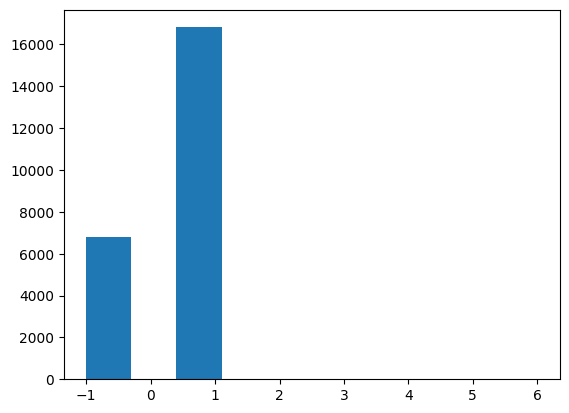

In [16]:
plt.hist(DBSCAN_labels)

(array([16942.,     0.,     0.,   877.,     0.,     0.,  4123.,     0.,
            0.,  1714.]),
 array([0. , 0.3, 0.6, 0.9, 1.2, 1.5, 1.8, 2.1, 2.4, 2.7, 3. ]),
 <BarContainer object of 10 artists>)

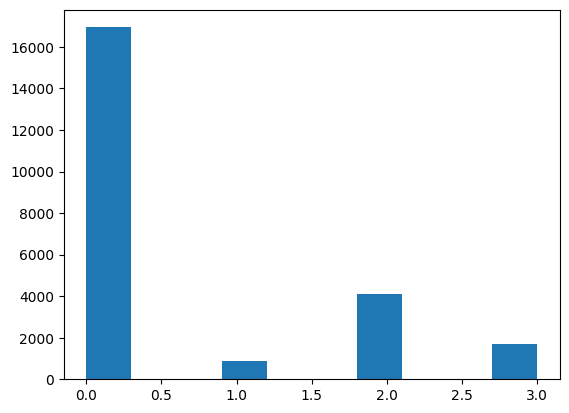

In [17]:
plt.hist(kmeans_labels)

In [18]:
latents_2d = UMAP_train(latent_array_np, result_dir)




/home/ldin/.local/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [19]:
# from sklearn.manifold import TSNE
# tsne = TSNE(n_components=2, perplexity=30, random_state=42)
# tsne_latents_2d = tsne.fit_transform(latent_array_np)

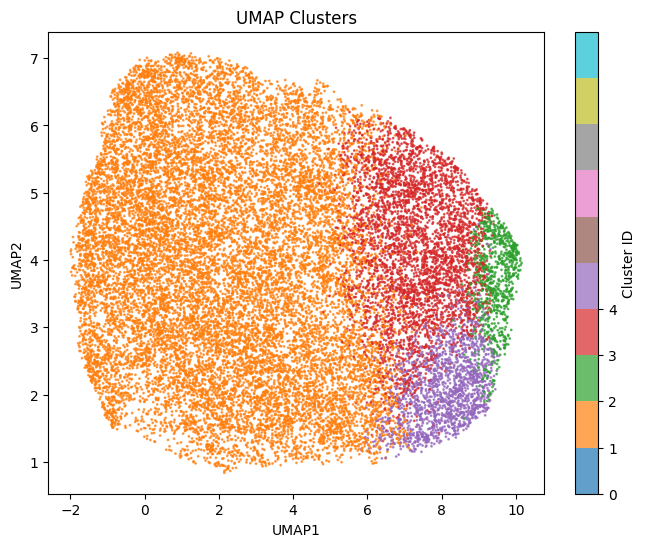

In [20]:
fig = plt.figure(figsize=(8, 6))
sc = plt.scatter(
    latents_2d[:, 0], latents_2d[:, 1],
    c=kmeans_labels+1,
    cmap='tab10',      # or 'tab20' if you have many clusters
    alpha=0.7, s=1,vmin=0,vmax=10
)
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("UMAP Clusters")

# Add colorbar with tick labels for clusters
cbar = plt.colorbar(sc, ticks=range(len(np.unique(kmeans_labels))+1))
cbar.set_label("Cluster ID")

In [21]:
# fig = umap_2Dplot(tsne_latents_2d, 0,1,kmeans_labels)

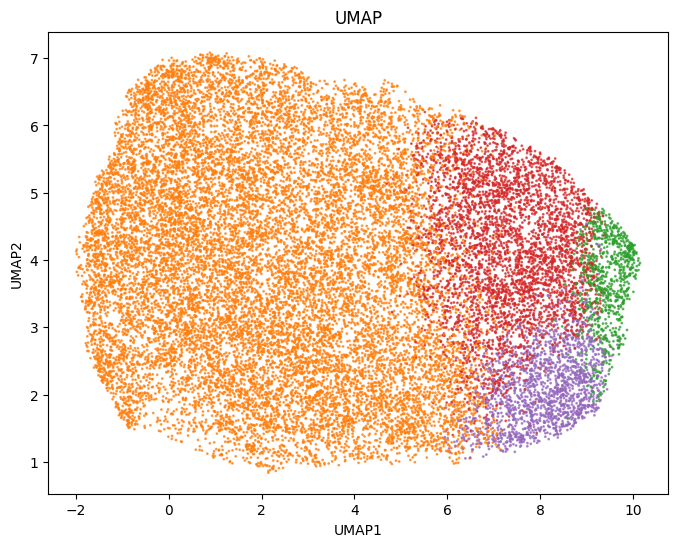

In [22]:
fig = umap_2Dplot(latents_2d, 0,1,kmeans_labels)

In [23]:
group_labels = patch_label_df['group_labels']

latents_2d[group_labels==0].shape

(12912, 2)

Text(0, 0.5, 'UMAP2')

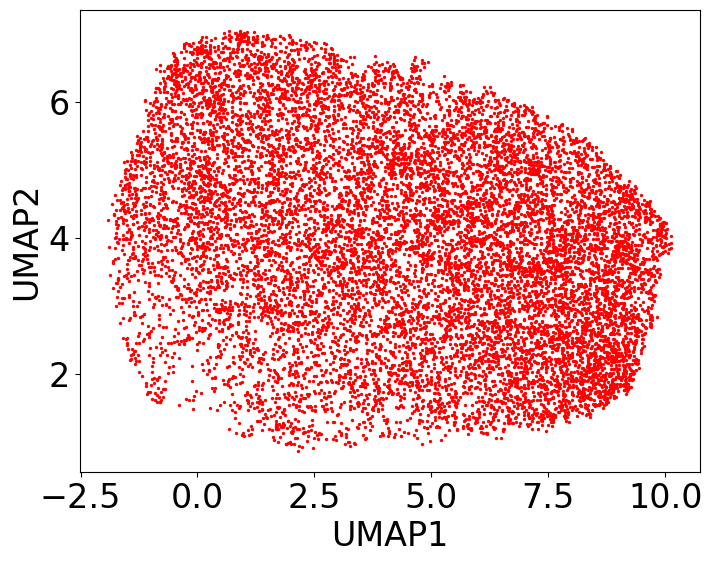

In [24]:
ctrl_latents_2d= latents_2d[group_labels==0]
y_latents_2d= latents_2d[group_labels==1]
# fig = umap_2Dplot(latents_2d[group_labels==1], 0,1,group_labels[group_labels==1]+2)
plt.rcParams.update({'font.size': 24})

fig = plt.figure(figsize=(8, 6))
plt.scatter(ctrl_latents_2d[:, 0], ctrl_latents_2d[:, 1], c='red',  s=2)
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
# plt.title("UMAP")  

Text(0, 0.5, 'UMAP2')

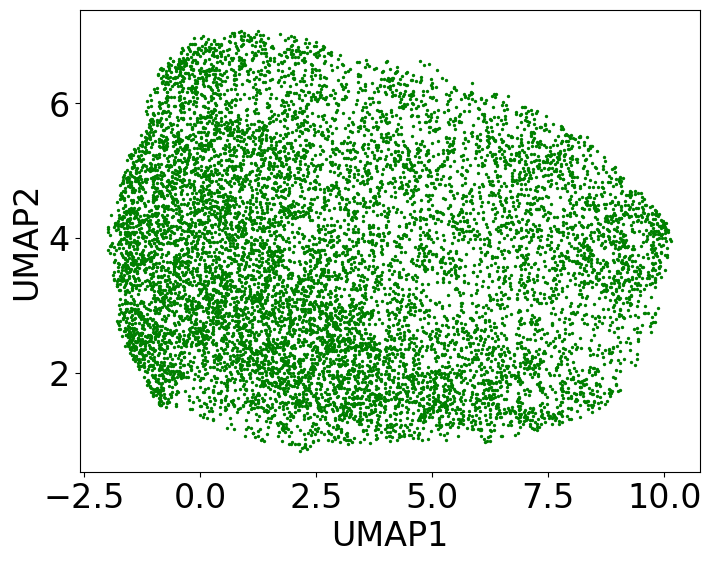

In [25]:

ctrl_latents_2d= latents_2d[group_labels==0]
y_latents_2d= latents_2d[group_labels==1]
# fig = umap_2Dplot(latents_2d[group_labels==1], 0,1,group_labels[group_labels==1]+2)
plt.rcParams.update({'font.size': 24})

fig = plt.figure(figsize=(8, 6))
plt.scatter(y_latents_2d[:, 0], y_latents_2d[:, 1], c='green',  s=2)
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
# plt.title("UMAP")  


In [26]:
# csv_folder = '/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/031125/ctrl_ch1_major/ctrl_ch1_patches_gridonly_wholecell_pslocation00/plot_patches32_40p_20250919_0948'
# csv_filename = 'data_prep_record_49_t49.csv'

# pad_size = 64
# import pandas as pd

# all_image_csv = pd.read_csv(os.path.join(csv_folder,csv_filename))

# unique_vals = all_image_csv["filename"].unique()
# latent_array =  []
# index_count=-1

# for filename in unique_vals:
#     this_file_csv = all_image_csv[all_image_csv["filename"]==filename]
#     # print(csv_filename)
#     raw_whole_image = np.zeros([1024,1024])
#     recon_whole_image = np.zeros([1024,1024])    
#     # raw_whole_image_RGB = np.zeros([3,1024,1024])
#     # recon_whole_image_RGB = np.zeros([3,1024,1024])    

#     for index, row in this_file_csv.iterrows():       
#         index_count = index_count+1 
#         x_corner1 = int(row["x_corner1"])
#         x_corner3 = int(row["x_corner3"])
#         y_corner1 = int(row["y_corner1"])
#         y_corner3 = int(row["y_corner3"])
#         patch_name = row['crop_img_filename']

                
#         raw_patch = tiff.imread(os.path.join(row["movie_partitioned_data_dir"],row["crop_img_filename"] ))
#         normed_raw_patch = raw_patch.copy() * 240 
#         normed_raw_patch[normed_raw_patch > 254] = 254
#         normed_raw_patch = normed_raw_patch/255
        
#         tensor_patch = torch.from_numpy(normed_raw_patch)
#         tensor_patch = tensor_patch.unsqueeze(0).unsqueeze(0)
#         tensor_patch = tensor_patch.to(device)
#         ae = ae.to(device)
#         with torch.no_grad():
#             recon_image, latent = ae(tensor_patch)
#         latent_array.append(latent)        

#         recon_patch_filename = 'nc'+str(int(kmeans_labels[index_count])).zfill(3) +"_recon_patch_"+patch_name+'.tif'
#         output_dir_cindex = os.path.join(recon_patch_dir,'c'+str(int(kmeans_labels[index_count])).zfill(3))
#         os.makedirs(output_dir_cindex, exist_ok=True)
#         tiff.imwrite(
#             os.path.join(output_dir_cindex,recon_patch_filename),
#             recon_image.squeeze().cpu().detach().numpy().astype(np.float32),
#             imagej=True,              # Write ImageJ metadata block
#             metadata={'axes': 'YX'}   # Or 'TYX', 'ZYX', etc. depending on shape
#         )    
        
#         raw_patch_img_filename = 'c'+str(int(kmeans_labels[index_count])).zfill(3) +"_raw_patch_"+patch_name+'.tif'
#         output_dir_cindex = os.path.join(raw_patch_dir,'c'+str(int(kmeans_labels[index_count])).zfill(3))
#         os.makedirs(output_dir_cindex, exist_ok=True)
#         tiff.imwrite(
#             os.path.join(output_dir_cindex,raw_patch_img_filename),
#             normed_raw_patch.astype(np.float32),
#             imagej=True,              # Write ImageJ metadata block
#             metadata={'axes': 'YX'}   # Or 'TYX', 'ZYX', etc. depending on shape
#         )
#         # raw_whole_image[y_corner1-pad_size:y_corner3-pad_size,x_corner1-pad_size:x_corner3-pad_size] = normed_raw_patch
#         # recon_whole_image[y_corner1-pad_size:y_corner3-pad_size,x_corner1-pad_size:x_corner3-pad_size] = recon_image.squeeze().cpu().detach()
#         # recon_whole_image_RGB[0,y_corner1-pad_size:y_corner3-pad_size,x_corner1-pad_size:x_corner3-pad_size] = recon_image.squeeze().cpu().detach()
#         # recon_whole_image_RGB[1,y_corner1-pad_size:y_corner3-pad_size,x_corner1-pad_size:x_corner3-pad_size] = recon_image.squeeze().cpu().detach()
#         # recon_whole_image_RGB[2,y_corner1-pad_size:y_corner3-pad_size,x_corner1-pad_size:x_corner3-pad_size] = recon_image.squeeze().cpu().detach()
#         # if(kmeans_labels[index_count]==0):
#         #     recon_whole_image_RGB[0,y_corner1-pad_size:y_corner3-pad_size,x_corner1-pad_size:x_corner3-pad_size] =1
#         # if(kmeans_labels[index_count]==1):
#         #     recon_whole_image_RGB[1,y_corner1-pad_size:y_corner3-pad_size,x_corner1-pad_size:x_corner3-pad_size] =1
#         # if(kmeans_labels[index_count]==2):
#         #     recon_whole_image_RGB[2,y_corner1-pad_size:y_corner3-pad_size,x_corner1-pad_size:x_corner3-pad_size] =1



#     # fig, ax = plt.subplots(1,2, figsize=(8,4))
#     # ax[0].imshow(raw_whole_image,cmap=plt.cm.gray)
#     # ax[1].imshow(recon_whole_image,cmap=plt.cm.gray)

#     # recon_img_filename = "recon_"+filename+'.tif'
    
#     # tiff.imwrite(
#     #     os.path.join(recon_dir,recon_img_filename),
#     #     recon_whole_image.astype(np.float32),#.swapaxes(0,2),
#     #     imagej=True,              # Write ImageJ metadata block
#     #     metadata={'axes': 'YX'}   # Or 'TYX', 'ZYX', etc. depending on shape
#     # )    
    
#     # raw_grid_img_filename = "raw_grid_"+filename+'.tif'
    
#     # tiff.imwrite(
#     #     os.path.join(raw_grid_dir,raw_grid_img_filename),
#     #     raw_whole_image.astype(np.float32),
#     #     imagej=True,              # Write ImageJ metadata block
#     #     metadata={'axes': 'YX'}   # Or 'TYX', 'ZYX', etc. depending on shape
#     # )

#     # break

In [27]:
patch_label_df['UMAP_d1']= latents_2d[:,0]
patch_label_df['UMAP_d2']= latents_2d[:,1]
patch_label_df.to_csv(os.path.join(recon_dir, 'patch_label_df.csv'))

In [28]:
# plt.boxplot(latent_array_np, whis=3)
# plt.ylim([-50,50])
# plt.title('Ctrl')

In [29]:
# plt.boxplot(latent_array_np[kmeans_labels==0], whis=3)
# plt.ylim([-50,50])
# plt.title('C0')

In [30]:
# plt.boxplot(latent_array_np[kmeans_labels==1], whis=3)
# plt.ylim([-50,50])
# plt.title('C1')

In [31]:
# plt.boxplot(latent_array_np[kmeans_labels==2], whis=3)
# plt.ylim([-50,50])
# plt.title('C2')

In [32]:
# plt.boxplot(latent_array_np[kmeans_labels==3], whis=3)
# plt.ylim([-50,50])
# plt.title('C3')

In [33]:
csv_folder = '/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/031125/y_ch1_major/y_ch1_patches_gridonly_wholecell_pslocation00/plot_patches32_40p_20250919_1005'
csv_filename = 'data_prep_record_40_t40.csv'
czifolder = '/mnt/d/lding/FA/data/FA_ML_Annabel_20250217/031125data/Ycomp'
import czifile
pad_size = 64
import pandas as pd

all_image_csv = pd.read_csv(os.path.join(csv_folder,csv_filename))

unique_vals = all_image_csv["filename"].unique()
latent_array =  []
index_count=-1

for filename in unique_vals:
    this_file_csv = all_image_csv[all_image_csv["filename"]==filename]

    raw_full_image = czifile.imread(os.path.join(czifolder, filename)).squeeze()
    
    # print(csv_filename)
    raw_whole_image = np.zeros([1024,1024])
    recon_whole_image = np.zeros([1024,1024])    
    # raw_whole_image_RGB = np.zeros([3,1024,1024])
    # recon_whole_image_RGB = np.zeros([3,1024,1024])    

    for index, row in this_file_csv.iterrows():       
        index_count = index_count+1 
        x_corner1 = int(row["x_corner1"])
        x_corner3 = int(row["x_corner3"])
        y_corner1 = int(row["y_corner1"])
        y_corner3 = int(row["y_corner3"])
        patch_name = row['crop_img_filename']


        matches = patch_label_df.index[
            (patch_label_df['crop_img_filename'] == patch_name) &
            (patch_label_df['ctrl_y_str'] == 'y')
        ]

        if len(matches) == 0:
            print("No matching row found:", patch_name)
        elif len(matches) > 1:
            print("Warning: multiple matches found:", patch_name)

        full_image_ind = matches[0]

        # full_image_ind = patch_label_df.index[patch_label_df['crop_img_filename'] == patch_name][0]

        vinculin_intensity = raw_full_image[0,y_corner1-pad_size:y_corner3-pad_size,x_corner1-pad_size:x_corner3-pad_size].mean()
        pax_intensity = raw_full_image[1,y_corner1-pad_size:y_corner3-pad_size,x_corner1-pad_size:x_corner3-pad_size].mean()
        actin_intensity = raw_full_image[-1,y_corner1-pad_size:y_corner3-pad_size,x_corner1-pad_size:x_corner3-pad_size].mean()

        patch_label_df.loc[full_image_ind, 'vinculin_intensity'] = vinculin_intensity
        patch_label_df.loc[full_image_ind, 'pax_intensity'] = pax_intensity
        patch_label_df.loc[full_image_ind, 'actin_intensity'] = actin_intensity

In [34]:
ctrl_y_str = 'ctrl_ch1_major'

seg_folder_str = 'code_org_20250820_seg'

cell_mask_folder = '/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/031125/'+ctrl_y_str+'/'+seg_folder_str+'/mask'

front_mask_dir = '/mnt/d/lding/FA/data/FA_ML_Annabel_20250217/031125data/frontmasks'

In [35]:
csv_folder = '/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/031125/ctrl_ch1_major/ctrl_ch1_patches_gridonly_wholecell_pslocation00/plot_patches32_40p_20250919_0948'
csv_filename = 'data_prep_record_49_t49.csv'
czifolder = '/mnt/d/lding/FA/data/FA_ML_Annabel_20250217/031125data/Control'
import czifile
pad_size = 64
import pandas as pd
import tifffile
from scipy.ndimage import distance_transform_cdt

all_image_csv = pd.read_csv(os.path.join(csv_folder,csv_filename))

unique_vals = all_image_csv["filename"].unique()
latent_array =  []
index_count=-1

for filename in unique_vals:
    this_file_csv = all_image_csv[all_image_csv["filename"]==filename]

    raw_full_image = czifile.imread(os.path.join(czifolder, filename)).squeeze()    
    cell_mask = tifffile.imread(os.path.join(cell_mask_folder, "cell_mask_"+filename+".tif")).squeeze().astype(float)
    


    distance_taxicab = distance_transform_cdt(cell_mask, metric="taxicab")
        
    # print(csv_filename)
    raw_whole_image = np.zeros([1024,1024])
    recon_whole_image = np.zeros([1024,1024])    
    # raw_whole_image_RGB = np.zeros([3,1024,1024])
    # recon_whole_image_RGB = np.zeros([3,1024,1024])    

    for index, row in this_file_csv.iterrows():       
        index_count = index_count+1 
        x_corner1 = int(row["x_corner1"])
        x_corner3 = int(row["x_corner3"])
        y_corner1 = int(row["y_corner1"])
        y_corner3 = int(row["y_corner3"])
        patch_name = row['crop_img_filename']

        matches = patch_label_df.index[
            (patch_label_df['crop_img_filename'] == patch_name) &
            (patch_label_df['ctrl_y_str'] == 'ctrl')
        ]

        if len(matches) == 0:
            print("No matching row found:", patch_name)
        elif len(matches) > 1:
            print("Warning: multiple matches found:", patch_name)

        full_image_ind = matches[0]

        

        # full_image_ind = patch_label_df.index[patch_label_df['crop_img_filename'] == patch_name][0]

        vinculin_intensity = raw_full_image[0,y_corner1-pad_size:y_corner3-pad_size,x_corner1-pad_size:x_corner3-pad_size].mean()
        pax_intensity = raw_full_image[1,y_corner1-pad_size:y_corner3-pad_size,x_corner1-pad_size:x_corner3-pad_size].mean()
        actin_intensity = raw_full_image[-1,y_corner1-pad_size:y_corner3-pad_size,x_corner1-pad_size:x_corner3-pad_size].mean()

        patch_label_df.loc[full_image_ind, 'vinculin_intensity'] = vinculin_intensity
        patch_label_df.loc[full_image_ind, 'pax_intensity'] = pax_intensity
        patch_label_df.loc[full_image_ind, 'actin_intensity'] = actin_intensity
        patch_label_df.loc[full_image_ind, 'dist_cell_edge'] = distance_taxicab[int((y_corner1+y_corner3)/2)-pad_size,int((x_corner1+x_corner3)/2)-pad_size]
                
        
    
    

In [36]:
csv_folder = '/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/031125/y_ch1_major/y_ch1_patches_gridonly_wholecell_pslocation00/plot_patches32_40p_20250919_1005'
csv_filename = 'data_prep_record_40_t40.csv'
czifolder = '/mnt/d/lding/FA/data/FA_ML_Annabel_20250217/031125data/Ycomp'
ctrl_y_str = 'y_ch1_major'
cell_mask_folder = '/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/031125/'+ctrl_y_str+'/'+seg_folder_str+'/mask'

import czifile
pad_size = 64
import pandas as pd
import tifffile
from scipy.ndimage import distance_transform_cdt

all_image_csv = pd.read_csv(os.path.join(csv_folder,csv_filename))

unique_vals = all_image_csv["filename"].unique()
index_count=-1

for filename in unique_vals:
    this_file_csv = all_image_csv[all_image_csv["filename"]==filename]

    raw_full_image = czifile.imread(os.path.join(czifolder, filename)).squeeze()    
    cell_mask = tifffile.imread(os.path.join(cell_mask_folder, "cell_mask_"+filename+".tif")).squeeze().astype(float)
    


    distance_taxicab = distance_transform_cdt(cell_mask, metric="taxicab")
        
    # print(csv_filename)
    raw_whole_image = np.zeros([1024,1024])
    recon_whole_image = np.zeros([1024,1024])    
    # raw_whole_image_RGB = np.zeros([3,1024,1024])
    # recon_whole_image_RGB = np.zeros([3,1024,1024])    

    for index, row in this_file_csv.iterrows():       
        index_count = index_count+1 
        x_corner1 = int(row["x_corner1"])
        x_corner3 = int(row["x_corner3"])
        y_corner1 = int(row["y_corner1"])
        y_corner3 = int(row["y_corner3"])
        patch_name = row['crop_img_filename']

        matches = patch_label_df.index[
            (patch_label_df['crop_img_filename'] == patch_name) &
            (patch_label_df['ctrl_y_str'] == 'y')
        ]

        if len(matches) == 0:
            print("No matching row found:", patch_name)
        elif len(matches) > 1:
            print("Warning: multiple matches found:", patch_name)

        full_image_ind = matches[0]

        

        # full_image_ind = patch_label_df.index[patch_label_df['crop_img_filename'] == patch_name][0]

        vinculin_intensity = raw_full_image[0,y_corner1-pad_size:y_corner3-pad_size,x_corner1-pad_size:x_corner3-pad_size].mean()
        pax_intensity = raw_full_image[1,y_corner1-pad_size:y_corner3-pad_size,x_corner1-pad_size:x_corner3-pad_size].mean()
        actin_intensity = raw_full_image[-1,y_corner1-pad_size:y_corner3-pad_size,x_corner1-pad_size:x_corner3-pad_size].mean()

        patch_label_df.loc[full_image_ind, 'vinculin_intensity'] = vinculin_intensity
        patch_label_df.loc[full_image_ind, 'pax_intensity'] = pax_intensity
        patch_label_df.loc[full_image_ind, 'actin_intensity'] = actin_intensity
        patch_label_df.loc[full_image_ind, 'dist_cell_edge'] = distance_taxicab[int((y_corner1+y_corner3)/2)-pad_size,int((x_corner1+x_corner3)/2)-pad_size]
                
        
    
    

In [37]:
patch_label_df

,Unnamed: 0.3,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,ctrl_y_str,crop_img_filename,group_labels,UMAP_d0,UMAP_d1,DBSCAN_labels,kmeans_labels,UMAP_d2,vinculin_intensity,pax_intensity,actin_intensity,dist_cell_edge
0,0,0,0,0,ctrl,f0000x0080y0816ps32.tif,0,0,7.362351,-1,3,2.153057,3470.368164,10741.897461,12359.537109,0.0
1,1,1,1,1,ctrl,f0000x0112y0784ps32.tif,0,0,6.147794,1,0,2.878139,2753.338867,8699.333984,13098.292969,0.0
2,2,2,2,2,ctrl,f0000x0144y0784ps32.tif,0,0,6.488678,-1,2,2.256219,4177.766602,12690.236328,16727.391602,8.0
3,3,3,3,3,ctrl,f0000x0176y0784ps32.tif,0,0,7.701843,-1,3,1.867148,3782.319336,9358.561523,17598.548828,4.0
4,4,4,4,4,ctrl,f0000x0240y0752ps32.tif,0,0,6.532968,-1,0,1.867843,3487.683594,8591.057617,16351.705078,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23651,23651,23651,23651,23651,y,f0040x0912y0624ps32.tif,1,0,-0.131142,1,0,4.729079,4753.446289,6024.557617,11125.858398,24.0
23652,23652,23652,23652,23652,y,f0040x0912y0656ps32.tif,1,0,6.295608,-1,0,1.541065,8459.265625,8512.615234,12954.887695,25.0
23653,23653,23653,23653,23653,y,f0040x0912y0688ps32.tif,1,0,0.798405,1,0,4.168520,7675.988281,8302.816406,8516.779297,28.0
23654,23654,23654,23654,23654,y,f0040x0912y0720ps32.tif,1,0,0.619416,1,0,3.967922,5432.383789,5537.922852,10739.161133,16.0


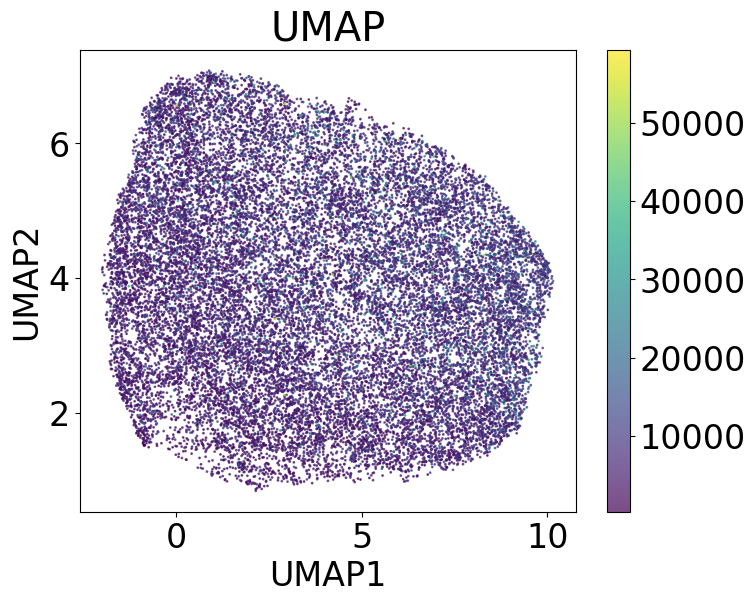

In [38]:
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(8, 6))
plt.scatter(patch_label_df['UMAP_d1'], patch_label_df['UMAP_d2'], c=patch_label_df['actin_intensity'],  alpha=0.7, s=1)
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("UMAP")  
plt.colorbar()

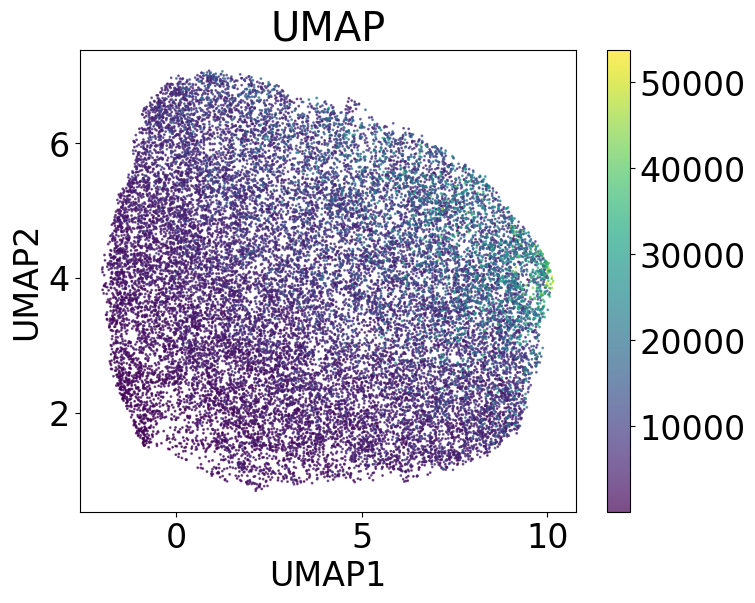

In [39]:
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(8, 6))
plt.scatter(patch_label_df['UMAP_d1'], patch_label_df['UMAP_d2'], c=patch_label_df['vinculin_intensity'],  alpha=0.7, s=1)
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("UMAP")  
plt.colorbar()

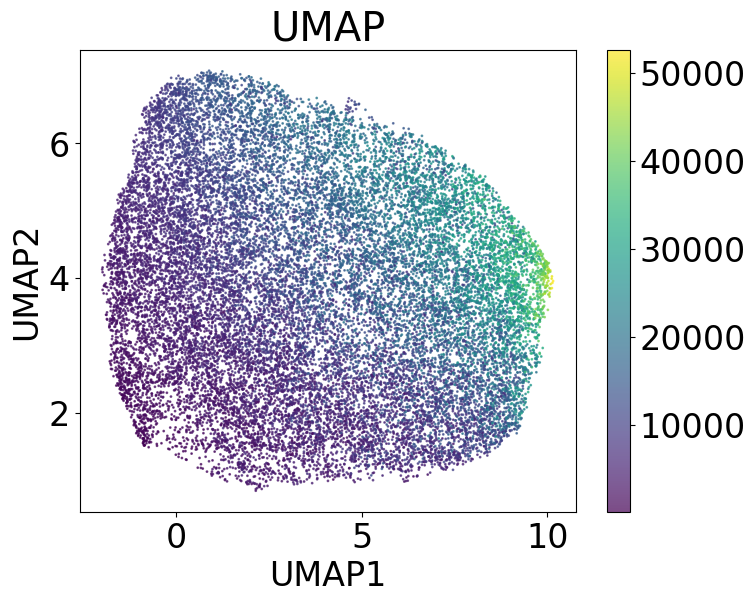

In [40]:
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(8, 6))
plt.scatter(patch_label_df['UMAP_d1'], patch_label_df['UMAP_d2'], c=patch_label_df['pax_intensity'],  alpha=0.7, s=1)
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("UMAP")  
plt.colorbar()

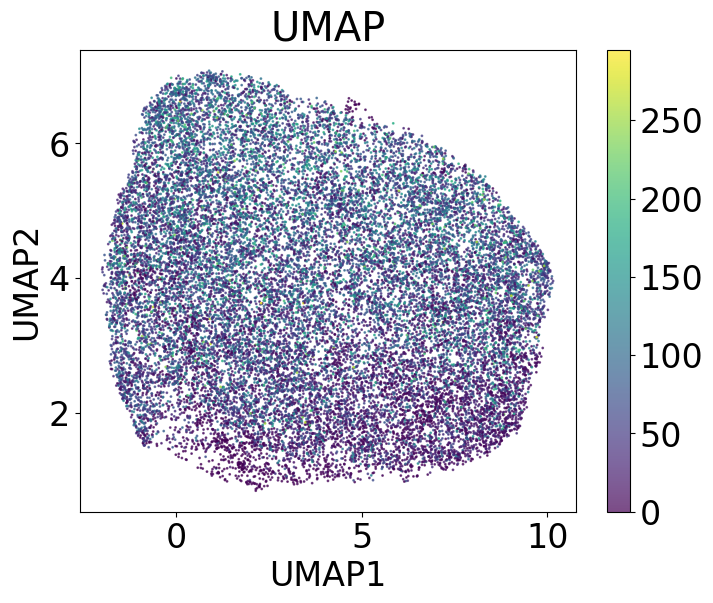

In [41]:

import matplotlib.pyplot as plt
fig = plt.figure(figsize=(8, 6))
plt.scatter(patch_label_df['UMAP_d1'], patch_label_df['UMAP_d2'], c=patch_label_df['dist_cell_edge'],  alpha=0.7, s=1)
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("UMAP")  
plt.colorbar()

In [42]:

import numpy as np

latent_array_np_plus4 = np.hstack([
    latent_array_np,
    np.zeros((latent_array_np.shape[0], 4))  # 4 new columns
])

latent_array_np_plus4[:,8] = patch_label_df['pax_intensity']
latent_array_np_plus4[:,9] = patch_label_df['vinculin_intensity']
latent_array_np_plus4[:,10] = patch_label_df['actin_intensity']
latent_array_np_plus4[:,11] = patch_label_df['dist_cell_edge']


In [58]:
latent_array_np_plus4[:,8] = latent_array_np_plus4[:,8]/np.percentile(latent_array_np_plus4[:,8],98)*15
latent_array_np_plus4[:,9] = latent_array_np_plus4[:,9]/np.percentile(latent_array_np_plus4[:,9],98)*10
latent_array_np_plus4[:,10] = latent_array_np_plus4[:,10]/np.percentile(latent_array_np_plus4[:,10],98)*5
latent_array_np_plus4[:,11] = latent_array_np_plus4[:,11]/np.percentile(latent_array_np_plus4[:,11],98)*5

In [59]:
for ind in range(0,12):
    print(latent_array_np_plus4[:,ind].std())

3.7737519860279103
3.2537987807140505
4.085686369620869
3.428099410816658
3.3052780514596343
3.129455912942868
2.940771179661435
4.215952017695369
3.6855593827730355
2.3750658121452464
1.1724255027766353
1.3666550197084553


{'whiskers': [<matplotlib.lines.Line2D at 0x7f635c289ff0>,
 'caps': [<matplotlib.lines.Line2D at 0x7f6354472f50>,
 'boxes': [<matplotlib.lines.Line2D at 0x7f635c288e80>,
 'medians': [<matplotlib.lines.Line2D at 0x7f6354473940>,
 'fliers': [<matplotlib.lines.Line2D at 0x7f63544737c0>,
 'means': []}

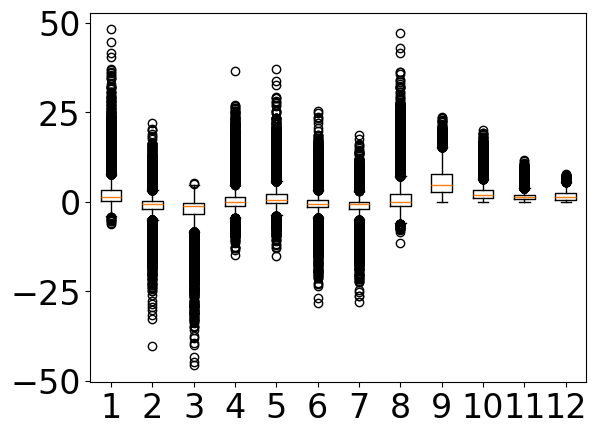

In [60]:
plt.boxplot(latent_array_np_plus4)

In [77]:
result_dir

'../results/ctrl_y_ch1_patches_gridonly_wholecell_pslocation00_lat8'

In [61]:
result_dir_plus4 = os.path.join(result_dir,'plus4')
os.makedirs(result_dir_plus4,exist_ok=True)
latents_plus4_2d = UMAP_train(latent_array_np_plus4, result_dir)

/home/ldin/.local/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [62]:
patch_label_df.columns

Index(['Unnamed: 0.3', 'Unnamed: 0.2', 'Unnamed: 0.1', 'Unnamed: 0',
       'ctrl_y_str', 'crop_img_filename', 'group_labels', 'UMAP_d0', 'UMAP_d1',
       'DBSCAN_labels', 'kmeans_labels', 'UMAP_d2', 'vinculin_intensity',
       'pax_intensity', 'actin_intensity', 'dist_cell_edge'],
      dtype='object')

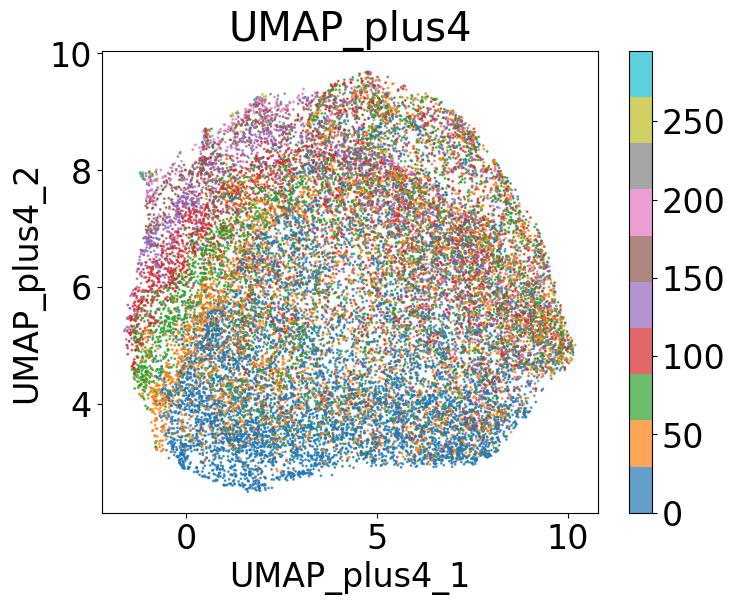

In [63]:
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(8, 6))
plt.scatter(latents_plus4_2d[:,0], latents_plus4_2d[:,1], c=patch_label_df['dist_cell_edge'], cmap='tab10', alpha=0.7, s=1)
plt.xlabel("UMAP_plus4_1")
plt.ylabel("UMAP_plus4_2")
plt.title("UMAP_plus4")  
plt.colorbar()

In [73]:
from sklearn.decomposition import PCA

pca = PCA(n_components=12)
latent_pca = pca.fit_transform(latent_array_np_plus4)

print(latent_pca.shape)   # (n_samples, 2)


(23656, 12)


In [74]:
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained:", pca.explained_variance_ratio_.sum())


Explained variance ratio: [0.39574105 0.14620417 0.0800603  0.07634809 0.06559453 0.0612159
 0.05916523 0.05573632 0.02472317 0.01598404 0.01021709 0.0090101 ]
Total explained: 0.9999999999999999


In [76]:
# fig = umap_2Dplot(latent_pca, 0,1,1-group_labels+1)

In [71]:
# import matplotlib.pyplot as plt
# fig = plt.figure(figsize=(8, 6))
# plt.scatter(latent_pca[:,0], latent_pca[:,1], c=2-group_labels+1,  alpha=0.7, s=1,cmap='tab20',vmin=0,vmax=1)
# plt.xlabel("pca_1")
# plt.ylabel("pca_2")
# plt.title("PCA")  
# plt.colorbar()

In [72]:
# import matplotlib.pyplot as plt
# fig = plt.figure(figsize=(8, 6))
# plt.scatter(latent_pca[:,0], latent_pca[:,1], c=patch_label_df['actin_intensity'],  alpha=0.7, s=1)
# plt.xlabel("pca_1")
# plt.ylabel("pca_2")
# plt.title("PCA")  
# plt.colorbar()

In [68]:
patch_label_df.columns

Index(['Unnamed: 0.3', 'Unnamed: 0.2', 'Unnamed: 0.1', 'Unnamed: 0',
       'ctrl_y_str', 'crop_img_filename', 'group_labels', 'UMAP_d0', 'UMAP_d1',
       'DBSCAN_labels', 'kmeans_labels', 'UMAP_d2', 'vinculin_intensity',
       'pax_intensity', 'actin_intensity', 'dist_cell_edge'],
      dtype='object')

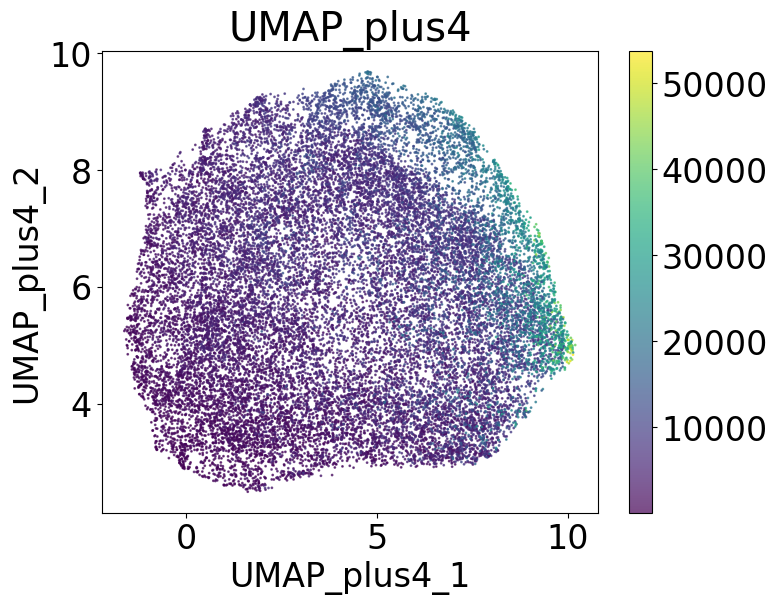

In [69]:
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(8, 6))
plt.scatter(latents_plus4_2d[:,0], latents_plus4_2d[:,1], c=patch_label_df['vinculin_intensity'],  alpha=0.7, s=1)
plt.xlabel("UMAP_plus4_1")
plt.ylabel("UMAP_plus4_2")
plt.title("UMAP_plus4")  
plt.colorbar()

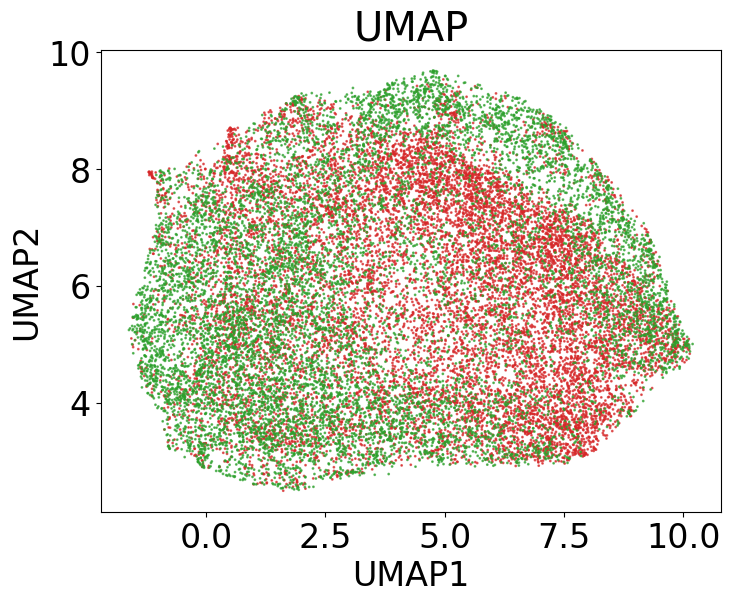

In [65]:
fig = umap_2Dplot(latents_plus4_2d, 0,1,1-group_labels+1)

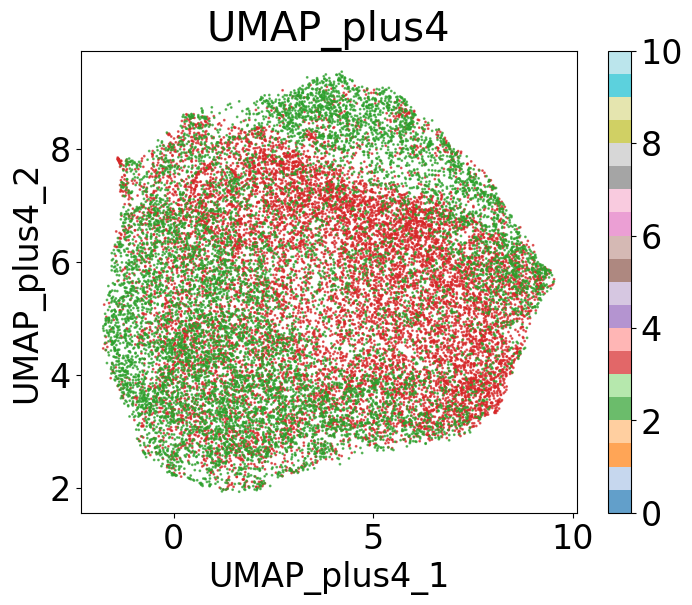

In [57]:
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(8, 6))
plt.scatter(latents_plus4_2d[:,0], latents_plus4_2d[:,1], c=2-group_labels+1, cmap='tab20', alpha=0.7, s=1, vmin=0, vmax=10)
plt.xlabel("UMAP_plus4_1")
plt.ylabel("UMAP_plus4_2")
plt.title("UMAP_plus4")  
plt.colorbar()

In [ ]:
# csv_folder = '/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/031125/ctrl_ch1_major/ctrl_ch1_patches_gridonly_wholecell_pslocation00/plot_patches32_40p_20250919_0948'
# csv_filename = 'data_prep_record_49_t49.csv'

# pad_size = 64
# import pandas as pd

# all_image_csv = pd.read_csv(os.path.join(csv_folder,csv_filename))

# unique_vals = all_image_csv["filename"].unique()
# latent_array =  []
# index_count=-1

# for filename in unique_vals:
#     this_file_csv = all_image_csv[all_image_csv["filename"]==filename]
#     # print(csv_filename)
#     raw_whole_image = np.zeros([1024,1024])
#     recon_whole_image = np.zeros([1024,1024])    
#     # raw_whole_image_RGB = np.zeros([3,1024,1024])
#     # recon_whole_image_RGB = np.zeros([3,1024,1024])    

#     for index, row in this_file_csv.iterrows():       
#         index_count = index_count+1 
#         x_corner1 = int(row["x_corner1"])
#         x_corner3 = int(row["x_corner3"])
#         y_corner1 = int(row["y_corner1"])
#         y_corner3 = int(row["y_corner3"])
#         patch_name = row['crop_img_filename']

                
#         raw_patch = tiff.imread(os.path.join(row["movie_partitioned_data_dir"],row["crop_img_filename"] ))
#         normed_raw_patch = raw_patch.copy() * 240 
#         normed_raw_patch[normed_raw_patch > 254] = 254
#         normed_raw_patch = normed_raw_patch/255
        
#         tensor_patch = torch.from_numpy(normed_raw_patch)
#         tensor_patch = tensor_patch.unsqueeze(0).unsqueeze(0)
#         tensor_patch = tensor_patch.to(device)
#         ae = ae.to(device)
#         with torch.no_grad():
#             recon_image, latent = ae(tensor_patch)
#         latent_array.append(latent)        

#         recon_patch_filename = 'nc'+str(int(kmeans_labels[index_count])).zfill(3) +"_recon_patch_"+patch_name+'.tif'
#         output_dir_cindex = os.path.join(recon_patch_dir,'c'+str(int(kmeans_labels[index_count])).zfill(3))
#         os.makedirs(output_dir_cindex, exist_ok=True)
#         tiff.imwrite(
#             os.path.join(output_dir_cindex,recon_patch_filename),
#             recon_image.squeeze().cpu().detach().numpy().astype(np.float32),
#             imagej=True,              # Write ImageJ metadata block
#             metadata={'axes': 'YX'}   # Or 'TYX', 'ZYX', etc. depending on shape
#         )    
        
#         raw_patch_img_filename = 'c'+str(int(kmeans_labels[index_count])).zfill(3) +"_raw_patch_"+patch_name+'.tif'
#         output_dir_cindex = os.path.join(raw_patch_dir,'c'+str(int(kmeans_labels[index_count])).zfill(3))
#         os.makedirs(output_dir_cindex, exist_ok=True)
#         tiff.imwrite(
#             os.path.join(output_dir_cindex,raw_patch_img_filename),
#             normed_raw_patch.astype(np.float32),
#             imagej=True,              # Write ImageJ metadata block
#             metadata={'axes': 'YX'}   # Or 'TYX', 'ZYX', etc. depending on shape
#         )
#         # raw_whole_image[y_corner1-pad_size:y_corner3-pad_size,x_corner1-pad_size:x_corner3-pad_size] = normed_raw_patch
#         # recon_whole_image[y_corner1-pad_size:y_corner3-pad_size,x_corner1-pad_size:x_corner3-pad_size] = recon_image.squeeze().cpu().detach()
#         # recon_whole_image_RGB[0,y_corner1-pad_size:y_corner3-pad_size,x_corner1-pad_size:x_corner3-pad_size] = recon_image.squeeze().cpu().detach()
#         # recon_whole_image_RGB[1,y_corner1-pad_size:y_corner3-pad_size,x_corner1-pad_size:x_corner3-pad_size] = recon_image.squeeze().cpu().detach()
#         # recon_whole_image_RGB[2,y_corner1-pad_size:y_corner3-pad_size,x_corner1-pad_size:x_corner3-pad_size] = recon_image.squeeze().cpu().detach()
#         # if(kmeans_labels[index_count]==0):
#         #     recon_whole_image_RGB[0,y_corner1-pad_size:y_corner3-pad_size,x_corner1-pad_size:x_corner3-pad_size] =1
#         # if(kmeans_labels[index_count]==1):
#         #     recon_whole_image_RGB[1,y_corner1-pad_size:y_corner3-pad_size,x_corner1-pad_size:x_corner3-pad_size] =1
#         # if(kmeans_labels[index_count]==2):
#         #     recon_whole_image_RGB[2,y_corner1-pad_size:y_corner3-pad_size,x_corner1-pad_size:x_corner3-pad_size] =1



#     # fig, ax = plt.subplots(1,2, figsize=(8,4))
#     # ax[0].imshow(raw_whole_image,cmap=plt.cm.gray)
#     # ax[1].imshow(recon_whole_image,cmap=plt.cm.gray)

#     # recon_img_filename = "recon_"+filename+'.tif'
    
#     # tiff.imwrite(
#     #     os.path.join(recon_dir,recon_img_filename),
#     #     recon_whole_image.astype(np.float32),#.swapaxes(0,2),
#     #     imagej=True,              # Write ImageJ metadata block
#     #     metadata={'axes': 'YX'}   # Or 'TYX', 'ZYX', etc. depending on shape
#     # )    
    
#     # raw_grid_img_filename = "raw_grid_"+filename+'.tif'
    
#     # tiff.imwrite(
#     #     os.path.join(raw_grid_dir,raw_grid_img_filename),
#     #     raw_whole_image.astype(np.float32),
#     #     imagej=True,              # Write ImageJ metadata block
#     #     metadata={'axes': 'YX'}   # Or 'TYX', 'ZYX', etc. depending on shape
#     # )

#     # break

In [ ]:
latent_feature_percentile_array=np.zeros([8,101])

for lat_ind in range(0,8):
    for syn_percentile in range(0,101):
        latent_feature_percentile_array[lat_ind,syn_percentile ] = np.percentile(latent_array_np[lat_ind,:],syn_percentile)



In [ ]:
# get id of a nascent one
plt.ioff()  # disable automatic display in Jupyter

# csv_folder = '/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/031125/ctrl_ch1_major/ctrl_ch1_patches_localmax_rotation_pslocation00/plot_patches16_65p_20251015_1131'
csv_folder = '/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/031125/ctrl_ch1_major/ctrl_ch1_patches_gridonly_wholecell_pslocation00/plot_patches32_40p_20250919_0948'
csv_filename = 'data_prep_record_49_t49.csv'

pad_size = 64
import pandas as pd

all_image_csv = pd.read_csv(os.path.join(csv_folder,csv_filename))

unique_vals = all_image_csv["filename"].unique()
latent_array =  []
index_count=-1
nascent_id = 0
mature_id = 0
for filename in unique_vals:
    this_file_csv = all_image_csv[all_image_csv["filename"]==filename]

    for index, row in this_file_csv.iterrows():       
        index_count = index_count+1 
        x_corner1 = int(row["x_corner1"])
        x_corner3 = int(row["x_corner3"])
        y_corner1 = int(row["y_corner1"])
        y_corner3 = int(row["y_corner3"])
        patch_name = row['crop_img_filename']
        # print(patch_name)
        UMAP_d0 = patch_label_df[patch_label_df['crop_img_filename']==patch_name]['UMAP_d1']
        UMAP_d1 = patch_label_df[patch_label_df['crop_img_filename']==patch_name]['UMAP_d2']
        if len(UMAP_d0)==0:
            continue
        
        # if UMAP_d0.iloc[0] > 8.8 and UMAP_d1.iloc[0] < 1.9 and mature_id==0:
        if(patch_name=='f0049x0624y0304ps32.tif'):
            mature_id = index_count          
                                
            raw_patch = tiff.imread(os.path.join(row["movie_partitioned_data_dir"],row["crop_img_filename"] ))
            normed_raw_patch = raw_patch.copy() * 240 
            normed_raw_patch[normed_raw_patch > 254] = 254
            normed_raw_patch = normed_raw_patch/255
            fig1 = plt.imshow(normed_raw_patch)
            tensor_patch = torch.from_numpy(normed_raw_patch)
            tensor_patch = tensor_patch.unsqueeze(0).unsqueeze(0)
            tensor_patch = tensor_patch.to(device)
            ae = ae.to(device)
            with torch.no_grad():
                recon_image, latent = ae(tensor_patch)

            mature_sample_latent = latent.clone().detach().cpu().numpy()
            mature_sample_latent2D = [UMAP_d0.iloc[0], UMAP_d1.iloc[0]]
         
        if UMAP_d0.iloc[0] <-1 and UMAP_d1.iloc[0] < 1.9 and nascent_id==0:
            nascent_id = index_count          
                                
            raw_patch = tiff.imread(os.path.join(row["movie_partitioned_data_dir"],row["crop_img_filename"] ))
            normed_raw_patch = raw_patch.copy() * 240 
            normed_raw_patch[normed_raw_patch > 254] = 254
            normed_raw_patch = normed_raw_patch/255
            fig2 = plt.imshow(normed_raw_patch)
            
            tensor_patch = torch.from_numpy(normed_raw_patch)
            tensor_patch = tensor_patch.unsqueeze(0).unsqueeze(0)
            tensor_patch = tensor_patch.to(device)
            ae = ae.to(device)
            with torch.no_grad():
                recon_image, latent = ae(tensor_patch)

            nascent_sample_latent = latent.clone().detach().cpu().numpy()
            nascent_sample_latent2D = [UMAP_d0.iloc[0], UMAP_d1.iloc[0]]
        
            

In [ ]:
plt.ion()
fig = umap_2Dplot(latents_2d, 0,1,1-group_labels+1)
plt.plot([nascent_sample_latent2D[0],mature_sample_latent2D[0]], [nascent_sample_latent2D[1],mature_sample_latent2D[1]],linewidth=5)

In [ ]:
mature_sample_latent2D = [UMAP_d0.iloc[0], UMAP_d1.iloc[0]]

In [ ]:
mature_sample_latent2D

In [ ]:
mature_sample_latent2D

In [ ]:
patch_name

In [ ]:
nascent_id

In [ ]:
mature_id

In [ ]:
mature_sample_latent

In [ ]:
nascent_sample_latent

In [ ]:
interpolated = np.linspace(
    nascent_sample_latent, 
    mature_sample_latent, 
    num=11
)

print(interpolated.shape) 

In [ ]:
altered_latent.shape

In [ ]:
new_recon.cpu()

In [ ]:
plt.ion()
import matplotlib
matplotlib.rcParams['font.family'] = 'Arial'  # Or 'Times New Roman', 'DejaVu Sans', etc.
matplotlib.rcParams['font.size'] = 10 

fig,ax = plt.subplots(1,11)
for inter_id in range(0,11):
    altered_latent = interpolated[inter_id,0,:]
    # Decode it
    with torch.no_grad():
        new_recon = ae.decode(torch.from_numpy(altered_latent).float().to(device))
    ax[inter_id].imshow(new_recon.squeeze().cpu().detach().numpy().astype(np.float32),clim=(0,1), cmap='gray')
    ax[inter_id].axis('off')
    ax[inter_id].set_title('>')
ax[0].set_title('nascent')
ax[9].set_title('>')
ax[10].set_title('mature')


In [ ]:
plt.ioff()  # disable automatic display in Jupyter

# csv_folder = '/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/031125/ctrl_ch1_major/ctrl_ch1_patches_localmax_rotation_pslocation00/plot_patches16_65p_20251015_1131'
csv_folder = '/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/031125/ctrl_ch1_major/ctrl_ch1_patches_gridonly_wholecell_pslocation00/plot_patches32_40p_20250919_0948'
csv_filename = 'data_prep_record_49_t49.csv'

pad_size = 64
import pandas as pd

all_image_csv = pd.read_csv(os.path.join(csv_folder,csv_filename))

unique_vals = all_image_csv["filename"].unique()
latent_array =  []
index_count=-1

for filename in unique_vals:
    this_file_csv = all_image_csv[all_image_csv["filename"]==filename]


    for index, row in this_file_csv.iterrows():       
        index_count = index_count+1 
        x_corner1 = int(row["x_corner1"])
        x_corner3 = int(row["x_corner3"])
        y_corner1 = int(row["y_corner1"])
        y_corner3 = int(row["y_corner3"])
        patch_name = row['crop_img_filename']
        # print(patch_name)
        UMAP_d0 = patch_label_df[patch_label_df['crop_img_filename']==patch_name]['UMAP_d1']
        UMAP_d1 = patch_label_df[patch_label_df['crop_img_filename']==patch_name]['UMAP_d2']
        if len(UMAP_d0)==0:
            continue
        
        # if UMAP_d0.iloc[0] <8.8:
        #     continue
        # if UMAP_d1.iloc[0] > 2 :
        #     continue

        if index_count % 100 > 0: 
            continue
                            
        raw_patch = tiff.imread(os.path.join(row["movie_partitioned_data_dir"],row["crop_img_filename"] ))
        normed_raw_patch = raw_patch.copy() * 240 
        normed_raw_patch[normed_raw_patch > 254] = 254
        normed_raw_patch = normed_raw_patch/255
        
        tensor_patch = torch.from_numpy(normed_raw_patch)
        tensor_patch = tensor_patch.unsqueeze(0).unsqueeze(0)
        tensor_patch = tensor_patch.to(device)
        ae = ae.to(device)
        with torch.no_grad():
            recon_image, latent = ae(tensor_patch)

        latent_raw = latent.clone().detach().cpu().numpy()
        percent_str = ""
        for lat_ind in range(0,8):
            percentile = int(np.sum(np.array(latent_array_np[lat_ind,:]) <= latent_raw[0,lat_ind]) / len(latent_array_np[lat_ind,:]) * 100)
            percent_str = percent_str + "_L"+str(lat_ind) +"p"+str(percentile).zfill(2)

        
        for lat_ind in range(0,8):

            fig, ax = plt.subplots(3,11, figsize=(13, 6))
            for i in range(0,3):
                for j in range(0,11):
                    ax[i,j].axis('off')
            plt.suptitle(patch_name+', L'+str(lat_ind))

            percentile = int(np.sum(np.array(latent_array_np[lat_ind,:]) <= latent_raw[0,lat_ind]) / len(latent_array_np[lat_ind,:]) * 100)
            ax[0,int(percentile/10)].imshow(normed_raw_patch,clim=(0,1), cmap='gray')
            ax[0,int(percentile/10)].set_title("Raw, L"+str(lat_ind) +", p"+str(percentile).zfill(2))
            ax[1,int(percentile/10)].imshow(normed_raw_patch.astype(np.float32),clim=(0,1), cmap='gray')
            ax[1,int(percentile/10)].set_title("Recon, L"+str(lat_ind) +", p"+str(percentile).zfill(2))
            

            for syn_percentile in range(0,100,10):
                # Clone the latent vector to avoid in-place changes
                altered_latent = latent.clone().detach()

                altered_latent[0,lat_ind] = latent_feature_percentile_array[lat_ind,syn_percentile]

                # Decode it
                with torch.no_grad():
                    new_recon = ae.decode(altered_latent)
                ax[2,int(syn_percentile/10)].imshow(new_recon.squeeze().cpu().detach().numpy().astype(np.float32),clim=(0,1), cmap='gray')
                ax[2,int(syn_percentile/10)].set_title("p"+str(syn_percentile).zfill(2))

                recon_patch_filename = 'L'+str(lat_ind)+"_p"+str(syn_percentile).zfill(2)+"_recon_patch_"+patch_name+'.tif'
                output_dir_cindex = os.path.join(os.path.join(recon_patch_dir,'alter_lat_'+patch_name[:-4]),'L'+str(lat_ind))
                os.makedirs(output_dir_cindex, exist_ok=True)
                tiff.imwrite(
                    os.path.join(output_dir_cindex,recon_patch_filename),
                    new_recon.squeeze().cpu().detach().numpy().astype(np.float32),
                    imagej=True,              # Write ImageJ metadata block
                    metadata={'axes': 'YX'}   # Or 'TYX', 'ZYX', etc. depending on shape
                )   

            recon_patch_filename = 'L'+str(lat_ind)+"_recon_patch_"+patch_name+'.png'
            output_dir_cindex = os.path.join(recon_patch_dir,'alter_lat_'+patch_name[:-4])            
            fig.savefig(os.path.join(output_dir_cindex, recon_patch_filename))


        raw_patch_img_filename = "raw_patch_"+percent_str+"_"+patch_name+'.tif'
        output_dir_cindex = os.path.join(recon_patch_dir,'alter_lat_'+patch_name[:-4])
        os.makedirs(output_dir_cindex, exist_ok=True)
        tiff.imwrite(
            os.path.join(output_dir_cindex,raw_patch_img_filename),
            normed_raw_patch.astype(np.float32),
            imagej=True,              # Write ImageJ metadata block
            metadata={'axes': 'YX'}   # Or 'TYX', 'ZYX', etc. depending on shape
        )
        break
